In [ ]:

class Value:
	def __init__(self, data, cameFrom=(), operator=None):
		self.data = data
		self.cameFrom = set(cameFrom)
		self.operator = operator
		self.grad = 0;
		self._backwards = lambda: None;

	def __repr__(self):
		return f"Value({self.data})"

	def __add__(self, o:Value):
		ans=Value(self.data+o.data, (self, o), '+')
		def _backwards():
			self.grad += 1 * ans.grad
			o.grad += 1 * ans.grad
		ans._backwards = _backwards
		return ans
	
	def __sub__(self, o:Value):
		ans = Value(self.data - o.data, (self, o), '-')
		def _backwards():
			self.grad += 1 * ans.grad
			o.grad += -1 * ans.grad
		ans._backwards = _backwards
		return ans;
	
	
	def __mul__(self, o:Value):
		ans = Value(self.data * o.data, (self, o), '*')
		def _backwards():
			self.grad += o.data * ans.grad
			o.grad += self.data * ans.grad
		ans._backwards = _backwards
		return ans;

	def activate(self) -> Value:
		# leaky relu
		if (self.data < 0):
			ans = Value(self.data*0.01, (self,), "relu");
			def _backwards():
				self.grad += 0.01 * ans.grad;
			ans._backwards = _backwards;
			return ans;
		else:
			ans = Value(self.data, (self,), "relu");
			def _backwards():
				self.grad +=  1 * ans.grad;
			ans._backwards = _backwards;
			return ans;
	
	def backwards(self):
		visited  = set()
		top = [];
		self.grad=1;
		def topSort(v: Value):
			if (v in visited):
				return
			visited.add(v)
			for kid in v.cameFrom:
				topSort(kid);
			top.append(v);
		topSort(self)

		for v in reversed(top):
			v._backwards();






In [174]:
eps=0.0001
a = Value(-10)
b = Value(2+eps)


c = a-b
d = c.activate()
e = d + Value(5)

e.backwards()


In [175]:
import random

class Neuron:
	def __init__(self, nIn: int, linear: bool):
		self.w = [Value(random.uniform(-1, 1)) for _ in range(nIn)]
		self.b = Value(random.uniform(-1, 1))
		self.linear=linear
		pass

	def params(self):
		return self.w+[self.b];

	def __call__(self, xs: list[Value]):
		preActivation = sum((x*w for x, w in zip(xs, self.w)), self.b)
		return preActivation if self.linear else preActivation.activate()

class Layer:
	def __init__(self, nIn: int, nOut: int, isLinear: bool):
		self.neurons = [Neuron(nIn, isLinear) for _ in range(nOut)]
		self.isLinear = isLinear
		self.nIn = nIn
		pass

	def params(self):
		return [p for n in self.neurons for p in n.params()]
	
	def __call__(self, xs: list[Value]):
		assert(len(xs) == self.nIn)
		return [n(xs) for n in self.neurons];
		

class MLP:
	def __init__(self, nInputs: int, outLayerSizes: list[int]):
		layerSizes = [nInputs] + outLayerSizes;
		self.layers=[Layer(layerSizes[i], layerSizes[i+1], i != len(outLayerSizes)-1) for i in range(len(outLayerSizes))]
		pass

	def params(self):
		return [p for l in self.layers for p in l.params()]
	
	def __call__(self, xs: list[Value]):
		for layer in self.layers:
			xs = layer(xs);
		assert(len(xs) == 1)
		return xs[0]





In [1295]:
def functionToGuess(x: float)->float:
	return x*x+1



In [2350]:
model = MLP(1, [3, 3, 1]);
# model = Neuron(1, False);

# xs = [(random.uniform(0, 10), random.uniform(0, 10)) for _ in range(100)]
# ys = [functionToGuess(x) for x in xs]





In [2352]:
for _ in range(50):
	for param in model.params():
		param.grad = 0


	input = 2.
	prediction = model([Value(input)])
	answer = functionToGuess(input)
	diff = prediction - Value(answer)
	loss = diff*diff
	loss.backwards()

	learning_rate = 0.001

	for param in model.params():
		param.data -= loss.data * learning_rate * param.grad


	print(f"{loss=}")

loss=Value(0.08528565982986497)
loss=Value(0.0836627692525103)
loss=Value(0.08210181902960237)
loss=Value(0.08059928912130286)
loss=Value(0.07915192321614191)
loss=Value(0.07775670435598916)
loss=Value(0.0764108332262567)
loss=Value(0.07511170877634282)
loss=Value(0.07385691088271465)
loss=Value(0.07264418480700013)
loss=Value(0.07147142723527962)
loss=Value(0.07033667371343964)
loss=Value(0.0692380873179046)
loss=Value(0.06817394842189303)
loss=Value(0.06714264543519861)
loss=Value(0.06614266641082363)
loss=Value(0.06517259142496894)
loss=Value(0.06423108564826613)
loss=Value(0.06331689303598124)
loss=Value(0.062428830573438676)
loss=Value(0.06156578302032375)
loss=Value(0.06072669810400809)
loss=Value(0.059910582117618884)
loss=Value(0.05911649588355218)
loss=Value(0.058343551047413025)
loss=Value(0.057590906671169076)
loss=Value(0.056857766097629305)
loss=Value(0.056143374061311584)
loss=Value(0.05544701402332936)
loss=Value(0.05476800571024838)
loss=Value(0.05410570283888245)
loss=

In [2394]:
model = MLP(1, [5, 5, 1]);

for _ in range(500):
	for param in model.params():
		param.grad = 0


	input = 2.
	prediction = model([Value(input)])
	answer = functionToGuess(input)
	diff = prediction - Value(answer)
	loss = diff*diff
	loss.backwards()

	learning_rate = 0.0001

	for param in model.params():
		param.data -= loss.data * learning_rate * param.grad


	print(f"{loss=}")

loss=Value(20.138588202847796)
loss=Value(17.040282210827733)
loss=Value(14.543845365254485)
loss=Value(12.52152172882581)
loss=Value(10.877802182329907)
loss=Value(9.535539001660435)
loss=Value(8.432364817451905)
loss=Value(7.518663557423368)
loss=Value(6.75549951859144)
loss=Value(6.112548886236691)
loss=Value(5.566245060840081)
loss=Value(5.098238970617443)
loss=Value(4.6941795312383086)
loss=Value(4.342773375988891)
loss=Value(4.035070156375594)
loss=Value(3.763922645481312)
loss=Value(3.52357931549445)
loss=Value(3.30937619747872)
loss=Value(3.117502825220819)
loss=Value(2.9448234562109206)
loss=Value(2.788739646076336)
loss=Value(2.6470838952152014)
loss=Value(2.518036769796189)
loss=Value(2.4000618653750387)
loss=Value(2.291854420165742)
loss=Value(2.192300439546368)
loss=Value(2.1004439688726593)
loss=Value(2.015460724522774)
loss=Value(1.9366367184725608)
loss=Value(1.8633508293683188)
loss=Value(1.7950605117084564)
loss=Value(1.731290015115215)
loss=Value(1.671620622835292)
l

In [1309]:
learning_rate = 0.001

for param in model.params():
	print(f"Param had data {param.data} subtracting {loss.data * learning_rate * param.grad}")
	param.data -= loss.data * learning_rate * param.grad

Param had data 0.5707137602957704 subtracting -0.112971759691279
Param had data 0.8132265389927352 subtracting -0.0564858798456395


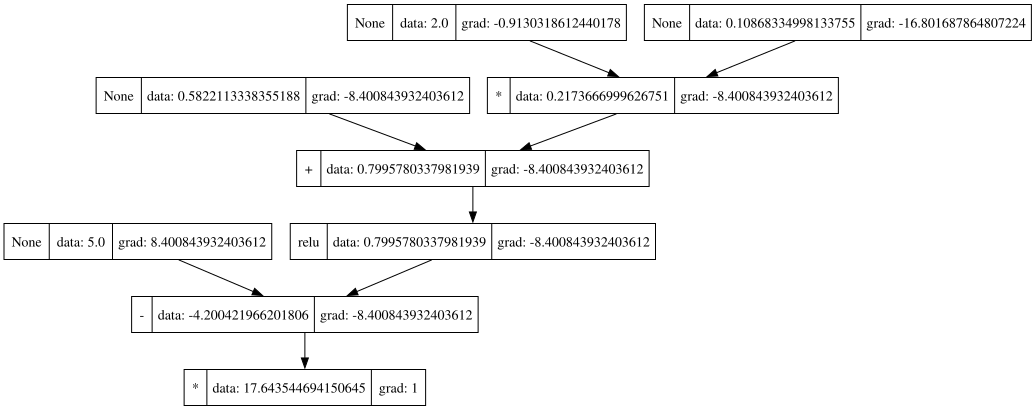

In [1302]:
from graphviz import Digraph

graph = Digraph()

def draw(v: Value) -> None:
	def stringID(value: Value) -> str:
		return str(id(value));
	
	graph.node(name=stringID(v), id=stringID(v), label=f"{v.operator} | data: {v.data} | grad: {v.grad}", shape="record")

	for kid in v.cameFrom:
		graph.edge(stringID(kid), stringID(v))
		draw(kid)

draw(loss)
graph